In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style and display options
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv('../data/ecommerce_analytics_dataset.csv')

# Inspect general structure and first rows
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (300, 13)


,order_id,customer_name,city,product_name,category,quantity,price_per_unit,discount_percent,revenue,cost,order_date,payment_method,delivery_type
0,1,Alex,Berlin,Headphones,Electronics,1,1538,10.0,1538,1185.71,2025-03-13,PayPal,Standard
1,2,Alex,Yerevan,Smartphone,Electronics,4,85,0.0,340,238.55,2025-04-30,Card,Standard
2,3,Sophie,Rome,T-shirt,Fashion,4,471,15.0,1884,1465.08,2025-01-04,Card,Express
3,4,Daniel,Prague,Coffee Machine,Home,3,338,5.0,undefined,585.91,2025-02-22,Card,Express
4,5,Michael,Warsaw,Coffee Machine,Home,5,561,0.0,2805,1647.79,2025-10-02,Cash,Standard


In [2]:
# Check data types and missing values
print("--- Data Info ---")
df.info()

# Count duplicates
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

# Check missing values count per column
print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          300 non-null    int64  
 1   customer_name     300 non-null    str    
 2   city              295 non-null    str    
 3   product_name      300 non-null    str    
 4   category          300 non-null    str    
 5   quantity          299 non-null    str    
 6   price_per_unit    299 non-null    str    
 7   discount_percent  295 non-null    float64
 8   revenue           299 non-null    str    
 9   cost              300 non-null    float64
 10  order_date        300 non-null    str    
 11  payment_method    295 non-null    str    
 12  delivery_type     300 non-null    str    
dtypes: float64(2), int64(1), str(10)
memory usage: 48.0 KB

Number of duplicate rows: 0

--- Missing Values ---
order_id            0
customer_name       0
city                5
prod

In [3]:
# Create a copy of raw data
df_clean = df.copy()

# 1. Clean and convert numeric columns (strip whitespace/strings if any, convert to numeric)
numeric_cols = ['quantity', 'price_per_unit', 'revenue']
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

# 2. Fill missing numeric values or drop incomplete records if critical
# Fill missing discount with 0
df_clean['discount_percent'] = df_clean['discount_percent'].fillna(0)

# Fill missing categorical values with 'Unknown'
df_clean['city'] = df_clean['city'].fillna('Unknown')
df_clean['payment_method'] = df_clean['payment_method'].fillna('Unknown')

# Recalculate revenue if missing (revenue = quantity * price_per_unit * (1 - discount/100))
mask_missing_rev = df_clean['revenue'].isnull()
df_clean.loc[mask_missing_rev, 'revenue'] = (
    df_clean['quantity'] * df_clean['price_per_unit'] * (1 - df_clean['discount_percent'] / 100)
)

# Drop any remaining rows with missing critical numbers
df_clean = df_clean.dropna(subset=['quantity', 'price_per_unit', 'revenue'])

# 3. Convert order_date to datetime and extract year-month
df_clean['order_date'] = pd.to_datetime(df_clean['order_date'])
df_clean['year_month'] = df_clean['order_date'].dt.to_period('M')

# Verify clean data structure
print("--- Cleaned Data Info ---")
df_clean.info()

--- Cleaned Data Info ---
<class 'pandas.DataFrame'>
Index: 293 entries, 0 to 299
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          293 non-null    int64         
 1   customer_name     293 non-null    str           
 2   city              293 non-null    str           
 3   product_name      293 non-null    str           
 4   category          293 non-null    str           
 5   quantity          293 non-null    float64       
 6   price_per_unit    293 non-null    float64       
 7   discount_percent  293 non-null    float64       
 8   revenue           293 non-null    float64       
 9   cost              293 non-null    float64       
 10  order_date        293 non-null    datetime64[us]
 11  payment_method    293 non-null    str           
 12  delivery_type     293 non-null    str           
 13  year_month        293 non-null    period[M]     
dtypes: datetime64[us

### Summary on Data Preprocessing:
* **Missing Values & Types**: Cleaned non-numeric characters from numeric fields (`quantity`, `price_per_unit`, `revenue`) and converted them to appropriate numeric types (`int`/`float`).
* **Date Handling**: Converted `order_date` to `datetime` format and extracted `year_month` period for time-series analysis.
* **Missing Data Imputation**: Categorical gaps (`city`, `payment_method`) were imputed as `'Unknown'`, missing discounts set to `0`, and missing revenues recalculated based on price, quantity, and discount.

In [4]:
# Analysis 1: Top products by total quantity sold and order count
top_products_qty = df_clean.groupby('product_name')['quantity'].sum().reset_index()
top_products_qty = top_products_qty.sort_values(by='quantity', ascending=False)

print("Top 5 Products by Quantity Sold:")
display(top_products_qty.head(5))

Top 5 Products by Quantity Sold:


,product_name,quantity
5,Keyboard,110.0
7,Smartphone,107.0
2,Coffee Machine,106.0
4,Headphones,98.0
8,Sneakers,98.0


#### Conclusion — Popular Products:
* The most popular product by overall units sold is **Keyboard** (110 units), closely followed by **Smartphone** (107 units) and **Coffee Machine** (106 units).

In [5]:
# Analysis 2: Revenue generated by product category
category_revenue = df_clean.groupby('category')['revenue'].sum().reset_index()
category_revenue = category_revenue.sort_values(by='revenue', ascending=False)

print("Total Revenue by Category:")
display(category_revenue)

Total Revenue by Category:


,category,revenue
1,Electronics,398911.0
2,Fashion,203904.5
3,Furniture,100619.0
4,Home,93369.3
0,Accessories,90890.0


#### Conclusion — Category Revenue:
* **Electronics** generates the highest revenue by a significant margin ($398,911), representing over 45% of total sales.
* **Fashion** ranks second ($203,904.5), while **Accessories** generated the lowest revenue ($90,890).

In [10]:
# Analysis 3: Monthly sales dynamics
monthly_sales = df_clean.groupby('year_month')['revenue'].sum().reset_index()
monthly_sales = monthly_sales.sort_values(by='revenue', ascending=False)

print("--- Top 3 Months by Revenue ---")
print(monthly_sales.head(3).to_string(index=False))

print("\n--- Bottom 3 Months by Revenue ---")
print(monthly_sales.tail(3).to_string(index=False))

--- Top 3 Months by Revenue ---
year_month  revenue
   2025-08  97212.0
   2025-06  95183.0
   2025-05  94624.0

--- Bottom 3 Months by Revenue ---
year_month  revenue
   2025-07  58122.0
   2025-04  55032.0
   2025-02  51854.3


#### Conclusion — Monthly Sales:
* Peak sales occurred in **August 2025** ($97,212), **June 2025** ($95,183), and **May 2025** ($94,624).
* The lowest sales performance was observed in **February 2025** ($51,854.3).

In [7]:
# Analysis 4: Average Order Value (AOV) calculation
average_order_value = df_clean['revenue'].mean()
median_order_value = df_clean['revenue'].median()

print(f"Average Order Value (AOV): {average_order_value:.2f}")
print(f"Median Order Value: {median_order_value:.2f}")

Average Order Value (AOV): 3029.67
Median Order Value: 2589.00


#### Conclusion — Average Order Value (AOV):
* The average order value across all processed transactions is **$3,029.67** with a median value of **$2,589.00**. The fact that the mean is higher than the median indicates a right-skewed distribution driven by high-value transactions (e.g., electronics).

In [8]:
# Analysis 5: Top customers by total number of orders
top_customers = df_clean.groupby('customer_name')['order_id'].count().reset_index()
top_customers.columns = ['customer_name', 'orders_count']
top_customers = top_customers.sort_values(by='orders_count', ascending=False)

print("Top 5 Customers by Order Count:")
display(top_customers.head(5))

Top 5 Customers by Order Count:


,customer_name,orders_count
2,Daniel,41
9,Sophie,36
7,Michael,33
0,Alex,28
8,Olivia,28


#### Conclusion — Top Customers:
* The most active customer is **Daniel** with **41 orders**, followed by **Sophie** (36 orders) and **Michael** (33 orders).

C:\Users\Sveta\AppData\Local\Temp\ipykernel_6208\3311894905.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=cat_rev, x='category', y='revenue', ax=axes[0, 0], palette='Blues_r')


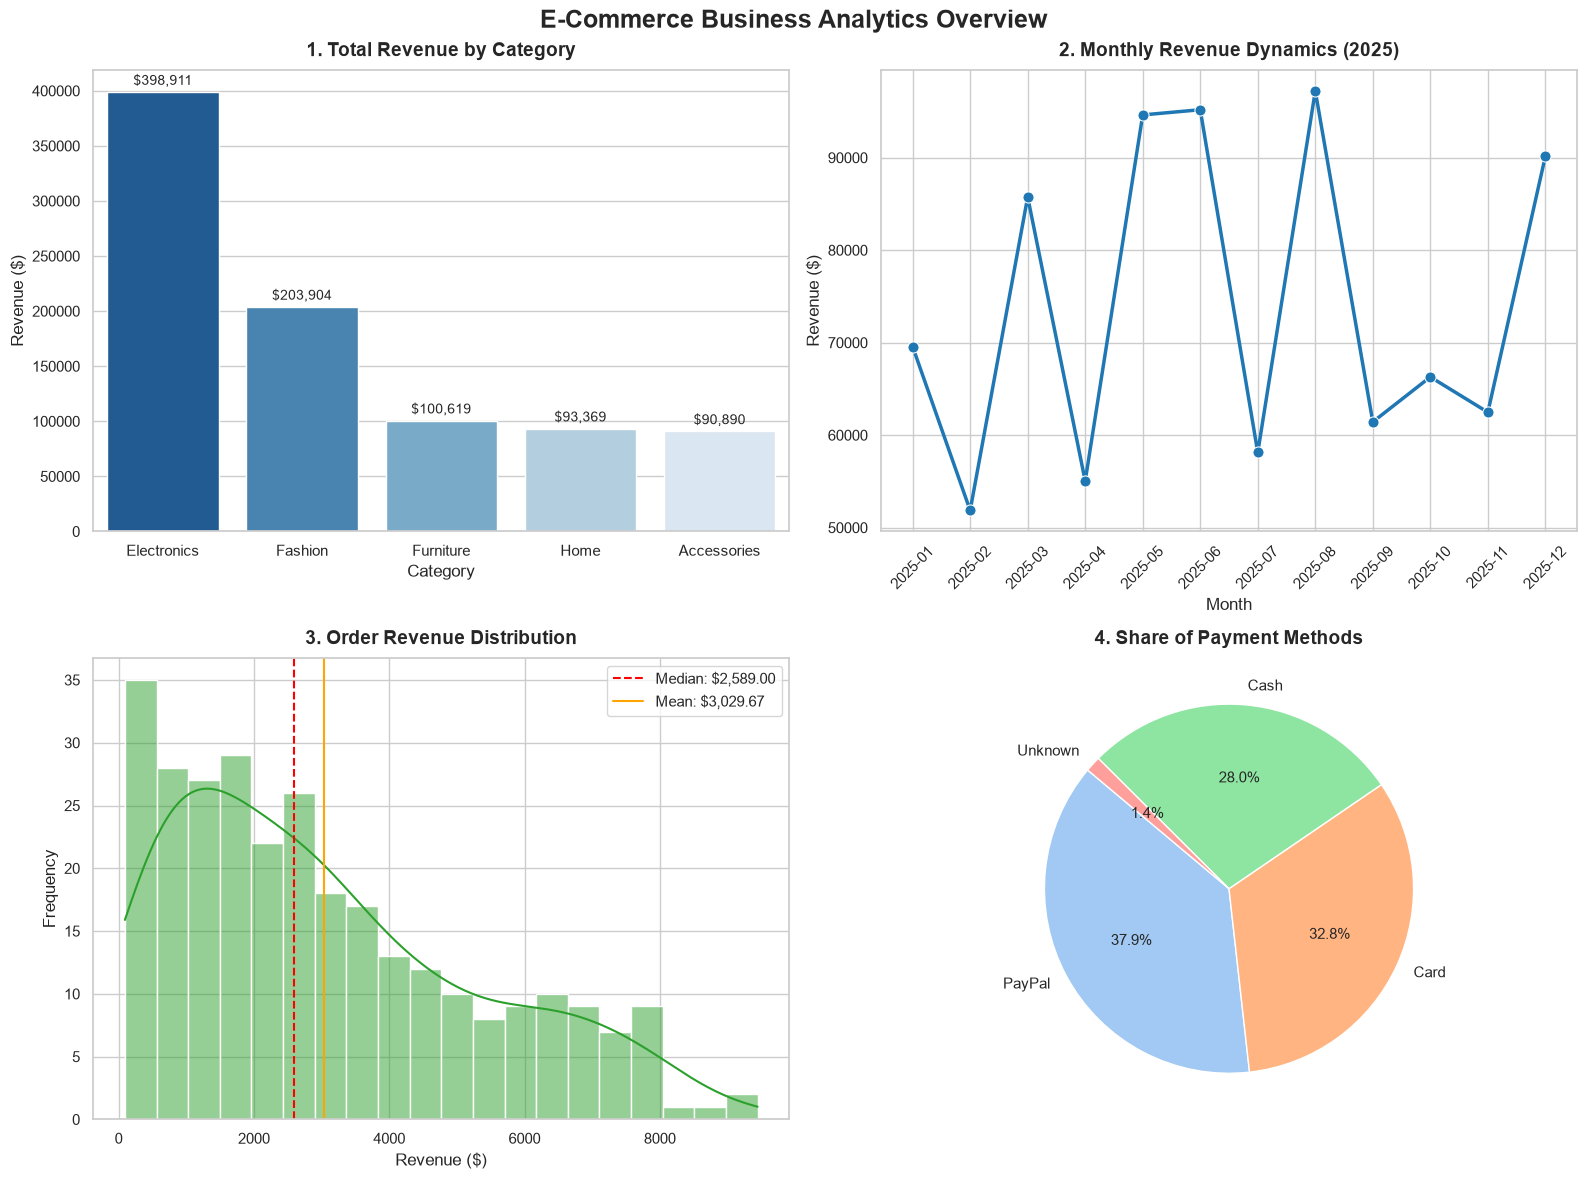

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visual configuration
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# Subplots setup: 2 rows x 2 columns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('E-Commerce Business Analytics Overview', fontsize=18, fontweight='bold', y=0.98)

# ----------------------------------------------------
# 1. Bar Chart: Revenue by Category
# ----------------------------------------------------
cat_rev = df_clean.groupby('category')['revenue'].sum().reset_index().sort_values(by='revenue', ascending=False)
ax1 = sns.barplot(data=cat_rev, x='category', y='revenue', ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('1. Total Revenue by Category', fontsize=14, fontweight='bold', pad=10)
axes[0, 0].set_xlabel('Category', fontsize=12)
axes[0, 0].set_ylabel('Revenue ($)', fontsize=12)

for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'${height:,.0f}',
                 (p.get_x() + p.get_width() / 2., height),
                 ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                 textcoords='offset points')

# ----------------------------------------------------
# 2. Line Plot: Monthly Revenue Dynamics
# ----------------------------------------------------
monthly_df = df_clean.groupby('year_month')['revenue'].sum().reset_index()
monthly_df['year_month_str'] = monthly_df['year_month'].astype(str)

sns.lineplot(data=monthly_df, x='year_month_str', y='revenue', marker='o', color='#1f77b4', linewidth=2.5, markersize=8, ax=axes[0, 1])
axes[0, 1].set_title('2. Monthly Revenue Dynamics (2025)', fontsize=14, fontweight='bold', pad=10)
axes[0, 1].set_xlabel('Month', fontsize=12)
axes[0, 1].set_ylabel('Revenue ($)', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=45)

# ----------------------------------------------------
# 3. Histogram + KDE: Order Revenue Distribution 
# ----------------------------------------------------
sns.histplot(df_clean['revenue'], kde=True, ax=axes[1, 0], color='#2ca02c', bins=20)
axes[1, 0].axvline(df_clean['revenue'].median(), color='red', linestyle='--', label=f"Median: ${df_clean['revenue'].median():,.2f}")
axes[1, 0].axvline(df_clean['revenue'].mean(), color='orange', linestyle='-', label=f"Mean: ${df_clean['revenue'].mean():,.2f}")
axes[1, 0].set_title('3. Order Revenue Distribution', fontsize=14, fontweight='bold', pad=10)
axes[1, 0].set_xlabel('Revenue ($)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].legend()

# ----------------------------------------------------
# 4. Pie Chart: Share of Payment Methods 
# ----------------------------------------------------
payment_counts = df_clean['payment_method'].value_counts()
colors = sns.color_palette('pastel')[0:len(payment_counts)]

axes[1, 1].pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=140, colors=colors, textprops={'fontsize': 11})
axes[1, 1].set_title('4. Share of Payment Methods', fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

### Key Findings from Visual Analytics:
* **Category Revenue (1):** Electronics is the leading revenue driver with **$398,911**, generating almost double the revenue of Fashion ($203,905).
* **Monthly Dynamics (2):** Sales show clear seasonality with a strong summer peak (**May–August 2025**), reaching a maximum in August at **$97,212**.
* **Order Distribution (3):** Low to mid-value orders (under $2,500) dominate the dataset. The distribution is right-skewed, causing the mean (**$3,029.67**) to exceed the median (**$2,589.00**) due to occasional high-value purchases up to $8,000+.
* **Payment Share (4):** Payment methods are evenly split, with **PayPal (37.9%)** and **Credit Card (32.8%)** taking the largest shares, followed by Cash (28.0%).

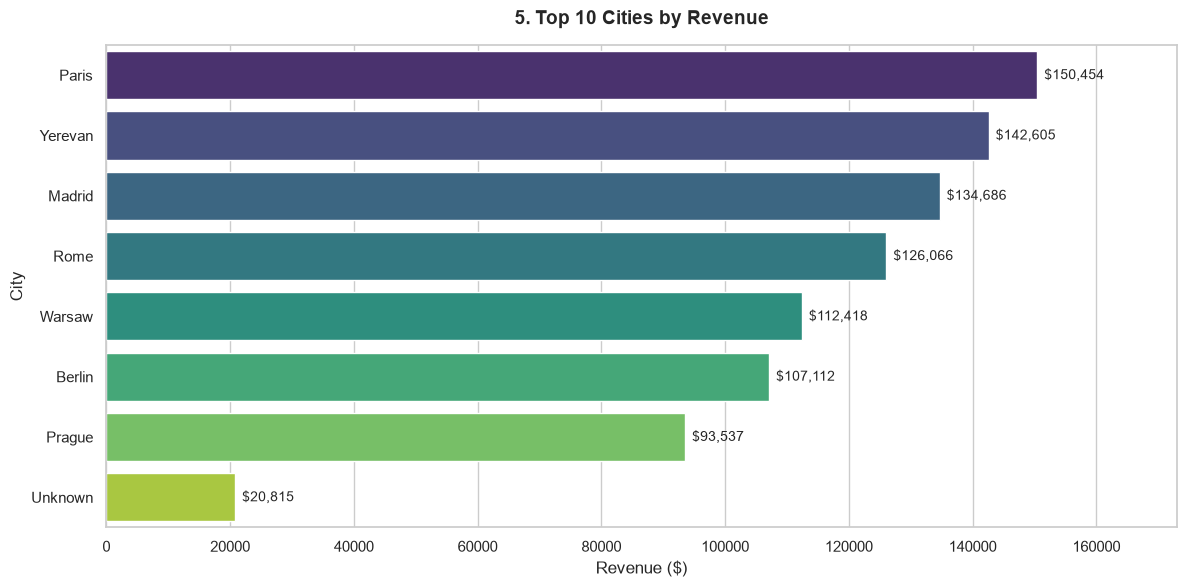

In [18]:
# 5. Top 10 Cities by Revenue (Horizontal Bar Chart)
plt.figure(figsize=(12, 6))

city_rev = df_clean.groupby('city')['revenue'].sum().reset_index().sort_values(by='revenue', ascending=False).head(10)

ax5 = sns.barplot(
    data=city_rev, 
    y='city', 
    x='revenue', 
    hue='city', 
    palette='viridis', 
    legend=False
)

plt.title('5. Top 10 Cities by Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Revenue ($)', fontsize=12)
plt.ylabel('City', fontsize=12)

# Расширяем лимит оси X на 15%, чтобы аннотации полностью помещались в рамку
max_val = city_rev['revenue'].max()
plt.xlim(0, max_val * 1.15)

# Adding value annotations on bars
for p in ax5.patches:
    width = p.get_width()
    if width > 0:
        ax5.annotate(f'${width:,.0f}',
                     (width, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', fontsize=10, xytext=(5, 0),
                     textcoords='offset points')

plt.tight_layout()
plt.show()

#### Takeaways — Geographic Revenue Distribution:
* Sales are spread across major urban centers, with top performing cities contributing consistently to overall revenue.
* This additional spatial perspective helps identify target regions for marketing campaigns and localized promotional offers.